# Time Series Analysis and Forecasting with Prophet

 **Goal:** 

- Explore the data (ECDF, handle missing values etc).
- Analysis per store type and correlational analysis of stores activity.
- Perform extensive Time Series Analysis (seasonal decomposition, trends, autocorrelation).
- Predict next 6 weeks of sales using Prophet (Facebook methodology).

This notebook mainly focuses on the *Time Series Analysis*. An important topic yet not covered. I use then *new methodology Prophet*, recently introduced by *Facebook,* to predict next 6 week of sales. This methodology has a cool feature of modeling for holidays. Finally, right at the end, I also discuss*advantages and drawbacks of forecasting with Seasonal ARIMA and Prophet.*

As it usually goes, we start with the Exploratory Data Analysis of the main metrics revealing present trends and patterns in the data, giving a solid foundation for the further (causal) analysis. 
<br> 
<br>
**WARNING**: 

It's a long read post but it's worth it. It might also need more time to run the script, but you can check out the full and *fast* version of the notebook on the [GitHub repository](https://github.com/elena-petrova/rossmann_TSA_forecasts).

Enjoy the reading!

![rossmann][1]


  [1]: https://kaggle2.blob.core.windows.net/competitions/kaggle/4594/media/rossmann_banner2.png

---

In [1]:
%%time
import warnings
warnings.filterwarnings("ignore")

# loading packages
# basic + dates 
import numpy as np
import pandas as pd
from datetime import datetime

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns # advanced vizs
%matplotlib inline

# statistics
from statsmodels.distributions.empirical_distribution import ECDF

# time series analysis
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# prophet by Facebook
# from fbprophet import Prophet

CPU times: user 3.22 s, sys: 164 ms, total: 3.38 s
Wall time: 1.3 s


In [2]:
%%time
train = pd.read_csv("rossmann-store-sales/train.csv", 
                    parse_dates = ['Date'], low_memory = False, index_col = 'Date')
store = pd.read_csv("rossmann-store-sales/store.csv", 
                    low_memory = False)
train.index

CPU times: user 371 ms, sys: 140 ms, total: 511 ms
Wall time: 511 ms


DatetimeIndex(['2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31', '2015-07-31', '2015-07-31',
               '2015-07-31', '2015-07-31',
               ...
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01', '2013-01-01', '2013-01-01',
               '2013-01-01', '2013-01-01'],
              dtype='datetime64[us]', name='Date', length=1017209, freq=None)

## EDA

In this first section we go through the train and store data, handle missing values and create new features for further analysis.

In [3]:
print("In total: ", train.shape)
train.head(5)

In total:  (1017209, 8)


,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
Date,,,,,,,,
2015-07-31,1,5,5263,555,1,1,0,1
2015-07-31,2,5,6064,625,1,1,0,1
2015-07-31,3,5,8314,821,1,1,0,1
2015-07-31,4,5,13995,1498,1,1,0,1
2015-07-31,5,5,4822,559,1,1,0,1


##### Short description:
- Sales: the turnover for any given day (target variable).
- Customers: the number of customers on a given day.
- Open: an indicator for whether the store was open: 0 = closed, 1 = open.
- Promo: indicates whether a store is running a promo on that day.
- StateHoliday: indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. 
- SchoolHoliday: indicates if the (Store, Date) was affected by the closure of public schools.

We are dealing with time series data so it will probably serve us to extract dates for further analysis. We also have two likely correlated vaiables in the dataset, which can be combined into a new feature.

In [4]:
# data extraction
train['Year'] = train.index.year
train['Month'] = train.index.month
train['Day'] = train.index.day
train['WeekOfYear'] = train.index.isocalendar().week #note

# adding new variable
train['SalePerCustomer'] = train['Sales']/train['Customers']
train['SalePerCustomer'].describe()

count    844340.000000
mean          9.493619
std           2.197494
min           0.000000
25%           7.895563
50%           9.250000
75%          10.899729
max          64.957854
Name: SalePerCustomer, dtype: float64

On average customers spend about 9.50$ per day. Though there are days with Sales equal to zero.

### ECDF: empirical cumulative distribution function

To get the first impression about continious variables in the data we can plot ECDF.
Hàm phân phối tích lũy thử nghiệm thể hiện phần trăm các sample trong một tập dữ liệu có giá trị nhỏ hơn hoặc bằng một mức nào đó.

Nhìn vào biểu đồ Sales, ta thấy biểu đồ nhảy đứng lên khoảng 0.17-0.18. Trong bộ dữ liệu này, có khoảng đâu đó 17-18% số ngày có daonh thu bằng 0. Đây có thể là các này nghỉ, lễ or missing data.

Biểu đồ Customers có hình dáng phần đầu giống y hệt biểu đồ Sales. Điều này hoàn toàn logic, vì nếu không có khách, tức là doanh thu = 0. Số lượng khách hàng dao động chủ yếu trong khoảng 1000 khách. Số lượng khách tối đa là 7000 nhưng rất hiếm, vì đường cong đã rất sát múc 1.0 từ rất sớm. 

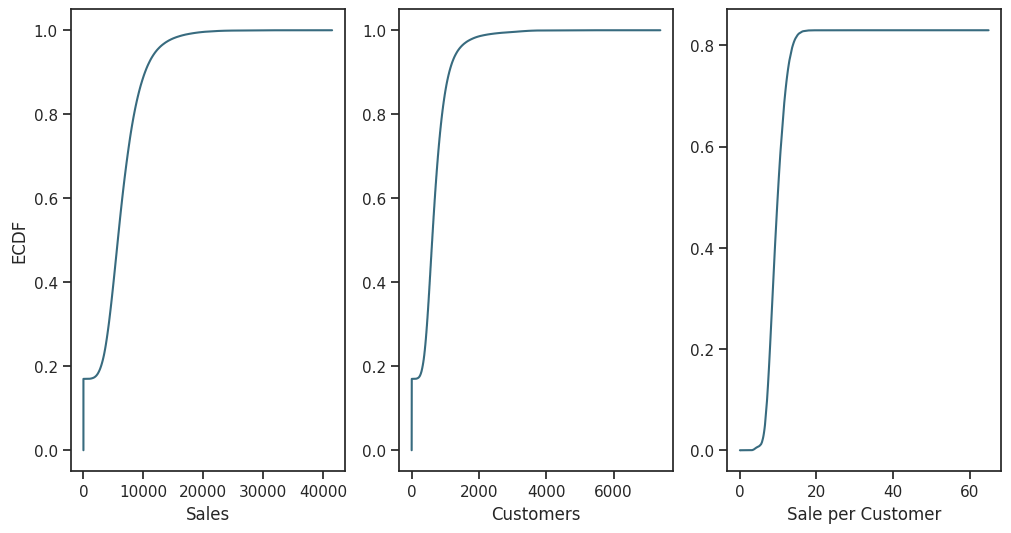

In [5]:
sns.set(style = "ticks")# to format into seaborn 
c = '#386B7F' # basic color for plots
plt.figure(figsize = (12, 6))

plt.subplot(131)
cdf = ECDF(train['Sales'])
plt.plot(cdf.x, cdf.y, label = "statmodels", color = c);
plt.xlabel('Sales'); plt.ylabel('ECDF');

# plot second ECDF  
plt.subplot(132)
cdf = ECDF(train['Customers'])
plt.plot(cdf.x, cdf.y, label = "statmodels", color = c);
plt.xlabel('Customers');

# plot second ECDF  
plt.subplot(133)
cdf = ECDF(train['SalePerCustomer'])
plt.plot(cdf.x, cdf.y, label = "statmodels", color = c);
plt.xlabel('Sale per Customer');

### Missing values 
#### Closed stores and zero sales stores

In [6]:
# closed stores
a = train[(train.Open == 0) & (train.Sales == 0)]
print("Total",a.shape)

Total (172817, 13)


Có thể thấy, gần 172817 ngày có cửa hàng đóng trên toàn bộ data (chiếm 17%). Để tránh bias, nhóm sẽ drop những giá trị này.

In [7]:
# opened stores with zero sales
a = train[(train.Open != 0) & (train.Sales == 0)]
print("Total", a.shape)


Total (54, 13)


Có khoảng 54 ngày dù mở nhưng lại không có doanh thu, có thể do vài lý do nào đó. 

In [8]:
print("Closed stores and days which didn't have any sales won't be counted into the forecasts.")
train = train[(train["Open"] != 0) & (train['Sales'] != 0)]

print("In total: ", train.shape)

Closed stores and days which didn't have any sales won't be counted into the forecasts.
In total:  (844338, 13)


What about store information:

In [9]:
# additional information about the stores
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


- Store: a unique Id for each store
- StoreType: differentiates between 4 different store models: a, b, c, d
- Assortment: describes an assortment level: a = basic, b = extra, c = extended
- CompetitionDistance: distance in meters to the nearest competitor store
- CompetitionOpenSince[Month/Year]: gives the approximate year and month of the time the nearest competitor was opened
- Promo2: Promo2 is a continuing a promotion for some stores: 0 = store is not participating, 1 = store is participating
- Promo2Since[Year/Week]: describes the year and calendar week when the store started participating in Promo2
- PromoInterval: describes the consecutive intervals Promo2 is started, naming the months the promotion is started. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

In [10]:
store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [11]:
# missing values?
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

We have few variables with missing values that we need to deal with. Let's start with the `CompetitionDistance`.

In [12]:
store.Promo2.dtype

dtype('int64')

In [13]:
store['CompetitionDistance'].describe()

count     1112.000000
mean      5404.901079
std       7663.174720
min         20.000000
25%        717.500000
50%       2325.000000
75%       6882.500000
max      75860.000000
Name: CompetitionDistance, dtype: float64

In [14]:
store[pd.isnull(store.CompetitionDistance)]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


Ta thấy rằng các giá trị NaN là ngẫu nhiên, nên nhóm quyết định thay thế giá trị này bằng một giá trị nào đó. Nhưng nhìn vào giá trị của mean và median, ta có thể thấy, dữ liệu đang bị right-skewed, túc là phần lớn data sẽ dồn về phía bên trái. Do đó, ta sẽ chọn median để điền vào các giá trị NaN

In [15]:
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())

In [16]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            0
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [17]:
a = store[pd.isnull(store.Promo2SinceWeek)]
b = store[pd.isnull(store.Promo2SinceYear)]
a_ = a[a.Promo2!=0] # nếu Promo2SinceWeek là NaN thì có tồn tại Promo != 0 không 
b_ = b[b.Promo2!=0] # tương tụ như v 
print("A", a_.shape)
print("B", b_.shape)

A (0, 10)
B (0, 10)


Có thể thấy, nếu không có Promo2 thì kéo theo giá trị Promo2SinceWeek và Promo2SinceYear cũng bằng 0. Vậy nếu không có giá trị Competition Distance thì sao? Hai giá trị liên quan là CompetitionOpenSinceMonth và CompetitionOpenSinceYear có bị kéo theo giống v không

In [18]:
# replace NA's by 0
num_cols = store.select_dtypes(include='number').columns
str_cols = store.select_dtypes(include='object').columns
store[num_cols] = store[num_cols].fillna(0)
store[str_cols] = store[str_cols].fillna('Unknown')


In [19]:
store.isnull().sum()

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [42]:
print("Joining train set with an additional store information.")
train = train.reset_index()
# by specifying inner join we make sure that only those observations 
# that are present in both train and store sets are merged together
train_store = pd.merge(train, store, how = 'inner', on = 'Store')

print("In total: ", train_store.shape)
train_store.head()

Joining train set with an additional store information.
In total:  (844338, 23)


,Date,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,...,SalePerCustomer,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,2015-07-31,1,5,5263,555,1,1,0,1,2015,...,9.482883,c,a,1270.0,9.0,2008.0,0,0.0,0.0,Unknown
1,2015-07-31,2,5,6064,625,1,1,0,1,2015,...,9.702400,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,2015-07-31,3,5,8314,821,1,1,0,1,2015,...,10.126675,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,2015-07-31,4,5,13995,1498,1,1,0,1,2015,...,9.342457,c,c,620.0,9.0,2009.0,0,0.0,0.0,Unknown
4,2015-07-31,5,5,4822,559,1,1,0,1,2015,...,8.626118,a,a,29910.0,4.0,2015.0,0,0.0,0.0,Unknown


In [43]:
len(train_store.Store.unique()) # có tổng cộng 1115 cửa hàng

1115

### Store types

In this section we will closely look at different levels of `StoreType` and how the main metric `Sales` is distributed among them.  

In [44]:
train_store.groupby('StoreType')['Sales'].describe()

,count,mean,std,min,25%,50%,75%,max
StoreType,,,,,,,,
a,457042.0,6925.697986,3277.351589,46.0,4695.25,6285.0,8406.00,41551.0
b,15560.0,10233.380141,5155.729868,1252.0,6345.75,9130.0,13184.25,38722.0
c,112968.0,6933.126425,2896.958579,133.0,4916.00,6408.0,8349.25,31448.0
d,258768.0,6822.300064,2556.401455,538.0,5050.00,6395.0,8123.25,38037.0


Loại cửa hàng (StoreType) B có Doanh thu (Sales) trung bình cao nhất so với các loại khác, tuy nhiên số lượng dữ liệu có về loại cửa hàng này lại ít hơn rất nhiều. Vì vậy, trực quan hơn thì tính tổng Doanh thu (Sales) và tổng Lượng khách (Customers) để xem loại cửa hàng (StoreType) nào thực sự bán được nhiều hàng nhất và đông khách nhất: 

In [45]:
train_store.groupby('StoreType')[['Customers', 'Sales']].sum()

,Customers,Sales
StoreType,,
a,363541431,3165334859
b,31465616,159231395
c,92129705,783221426
d,156904995,1765392943


Clearly stores of type A. `StoreType` D goes on the second place in both `Sales` and `Customers`.


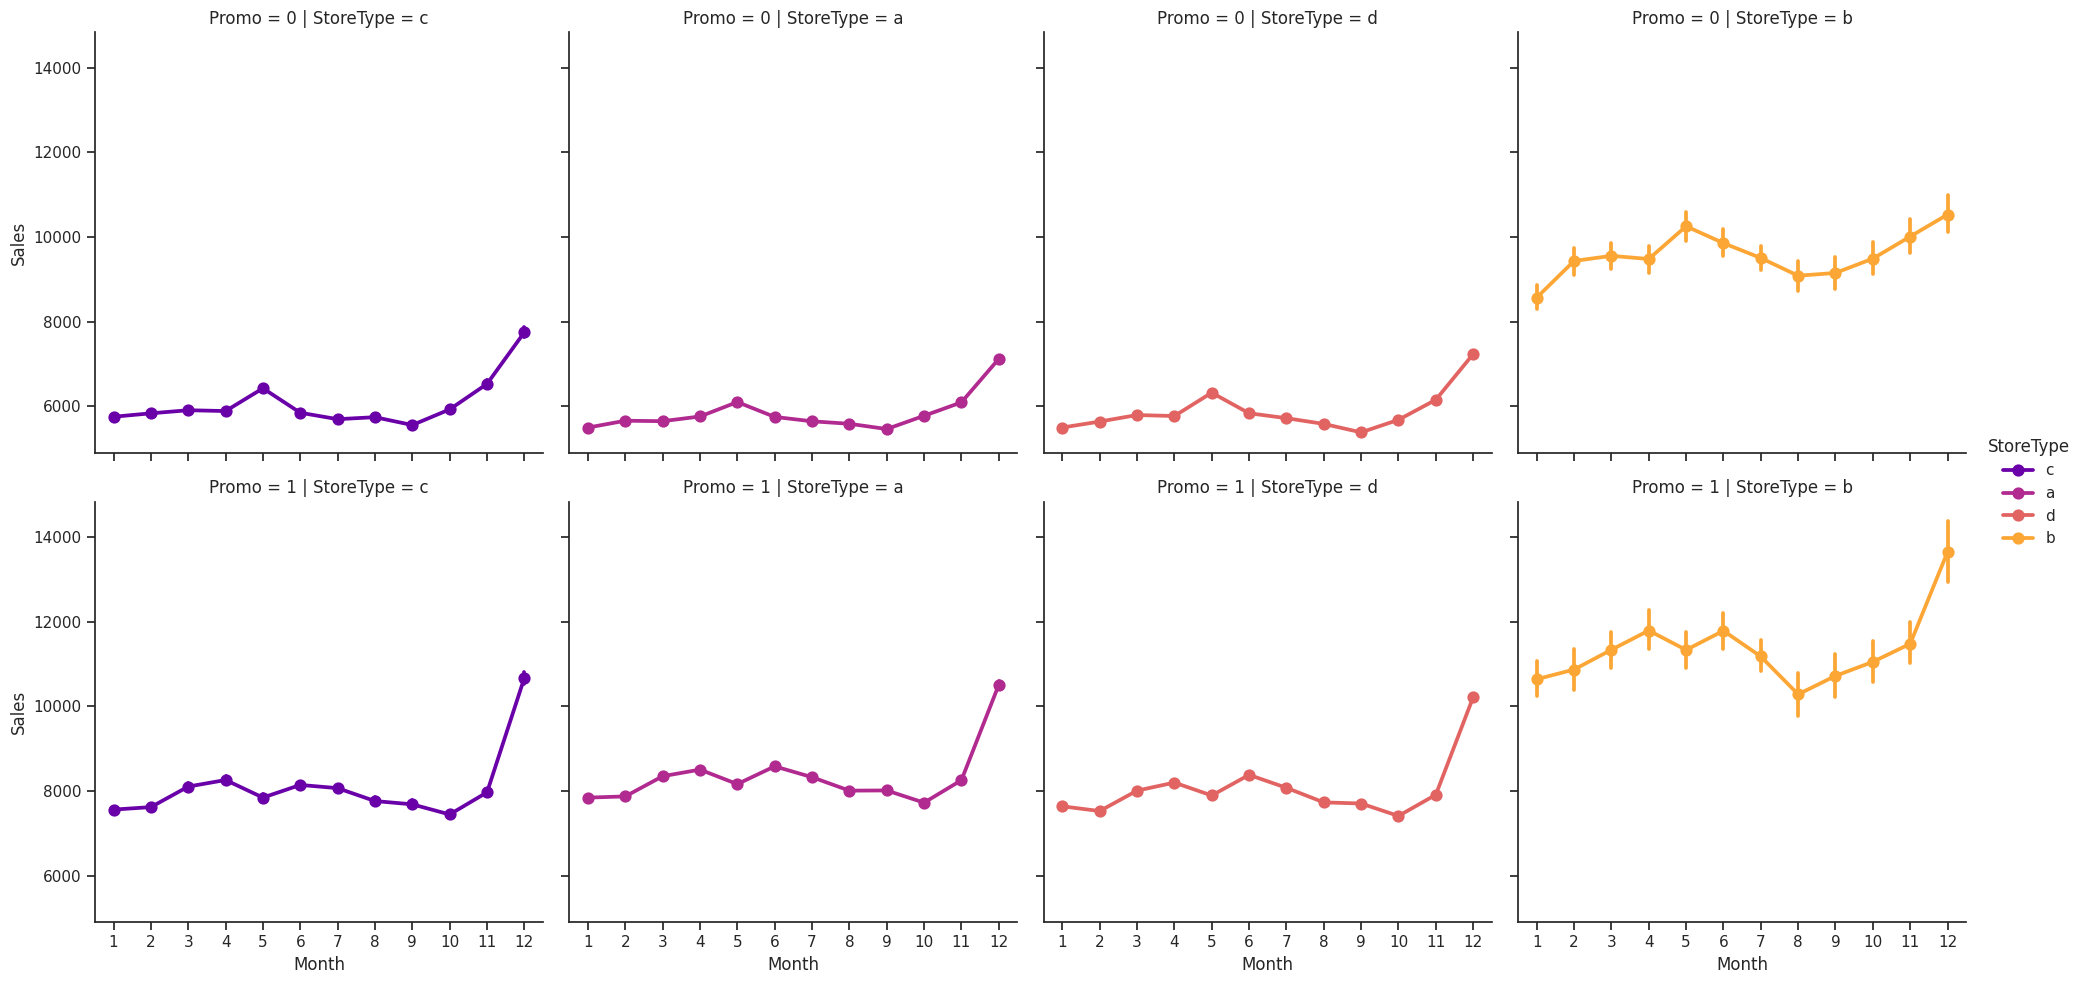

In [46]:
# sales trends
# catplot automatically calc average for each point in the diagram 
sns.catplot(data = train_store, 
            x = 'Month', 
            y = 'Sales', 
            col = 'StoreType', # Chia lưới theo cột: Loại cửa hàng
            row = 'Promo',     # Chia lưới theo hàng: Có/Không Khuyến mãi
            hue = 'StoreType', # Màu sắc phân biệt theo Loại cửa hàng
            palette = 'plasma',
            kind = 'point')    # Bắt buộc khai báo loại biểu đồ

# Hiển thị biểu đồ
plt.show()

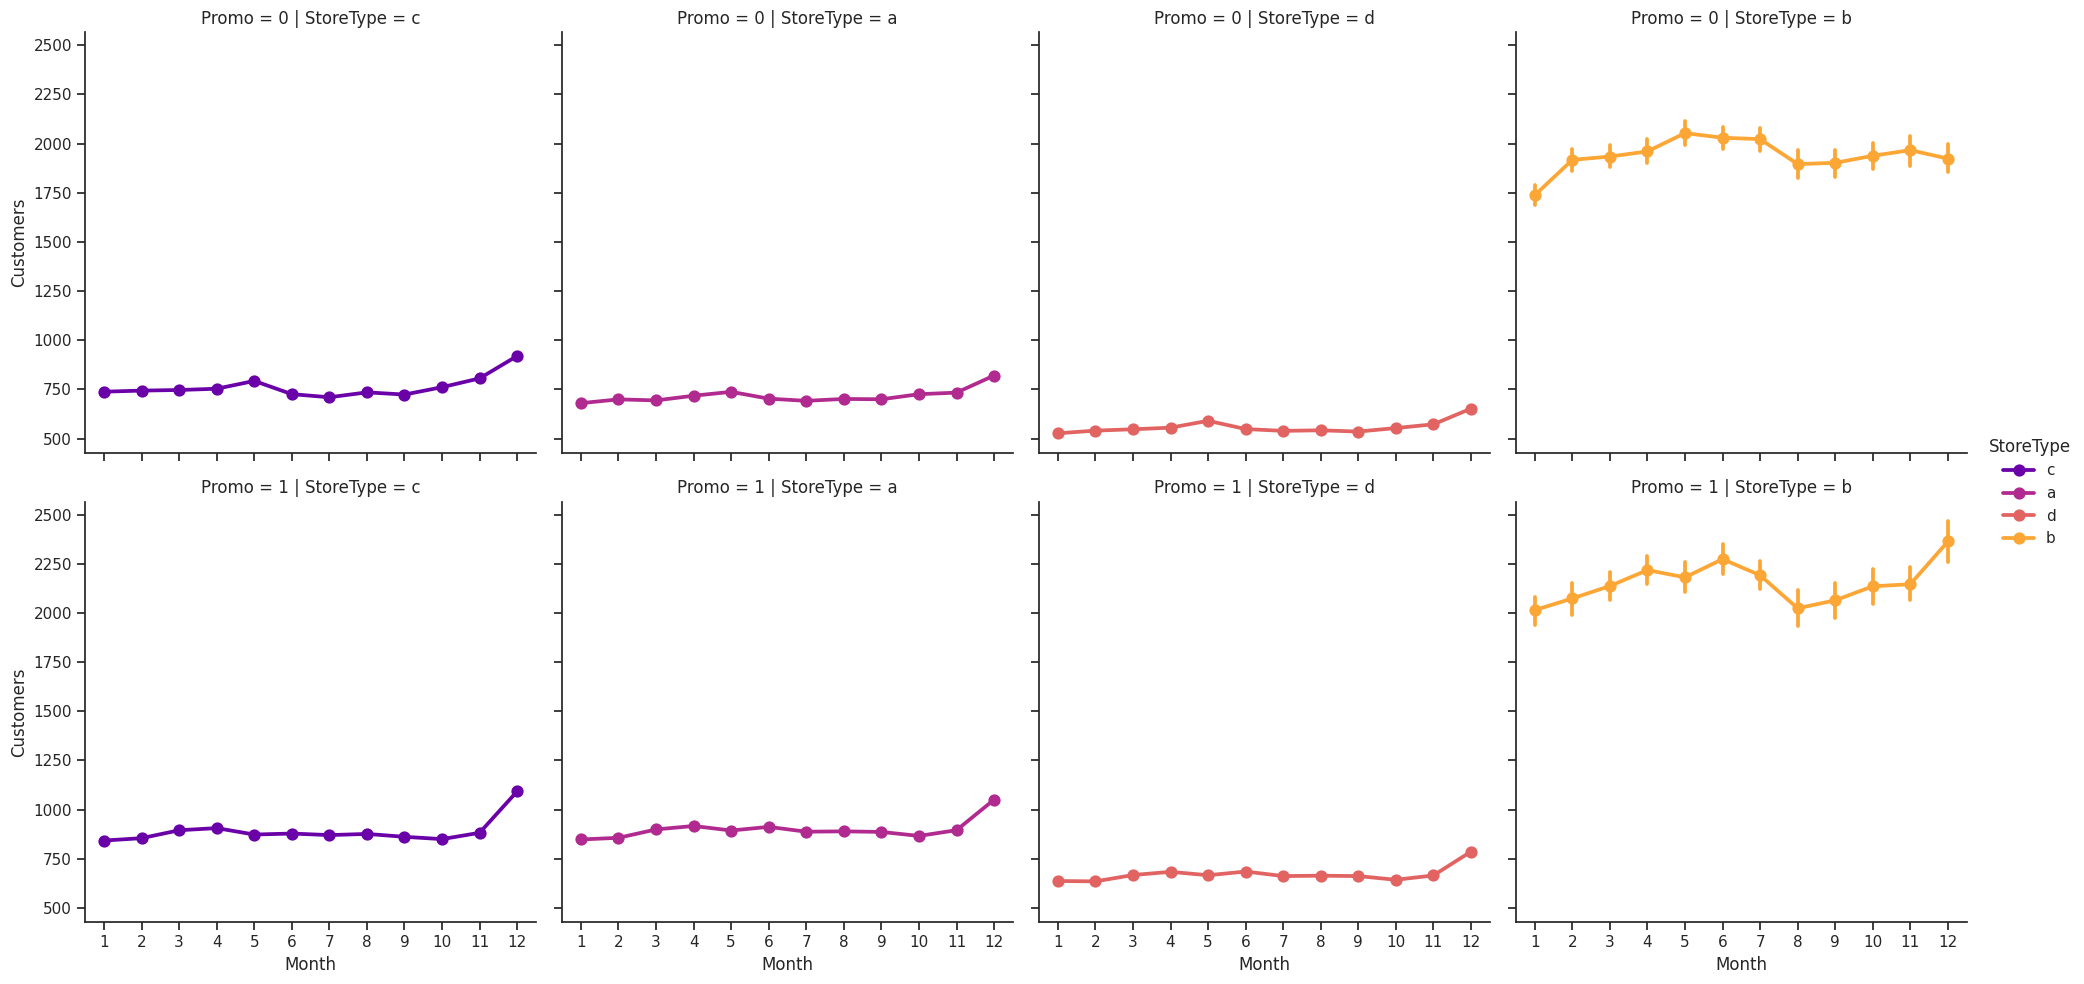

In [47]:
sns.catplot(data = train_store, 
            x = 'Month', 
            y = 'Customers',   # Trục Y bây giờ là Lượng khách hàng
            col = 'StoreType', # Chia cột theo Loại cửa hàng
            row = 'Promo',     # Chia hàng theo trạng thái Khuyến mãi
            hue = 'StoreType', # Màu sắc theo Loại cửa hàng
            palette = 'plasma',
            kind = 'point')    # Bắt buộc: Chọn vẽ dạng điểm nối tuyến

# Hiển thị biểu đồ
plt.show()

Tất cả các loại cửa hàng đều tuân theo cùng một xu hướng chung, nhưng ở những mức độ (quy mô) khác nhau tùy thuộc vào việc có áp dụng đợt khuyến mãi (Promo) hay không, cũng như phụ thuộc vào chính đặc thù của từng Loại cửa hàng (StoreType - điển hình là trường hợp của loại B).

Ngay tại bước phân tích này, nhóm đã có thể thấy rõ Doanh thu đang tăng vọt vào dịp nghỉ lễ Giáng sinh. Tuy nhiên, nhóm sẽ đi sâu hơn vào các yếu tố về tính mùa vụ (seasonalities) và xu hướng (trends) trong phần Phân tích Chuỗi thời gian (Time Series Analysis) ở phía sau.

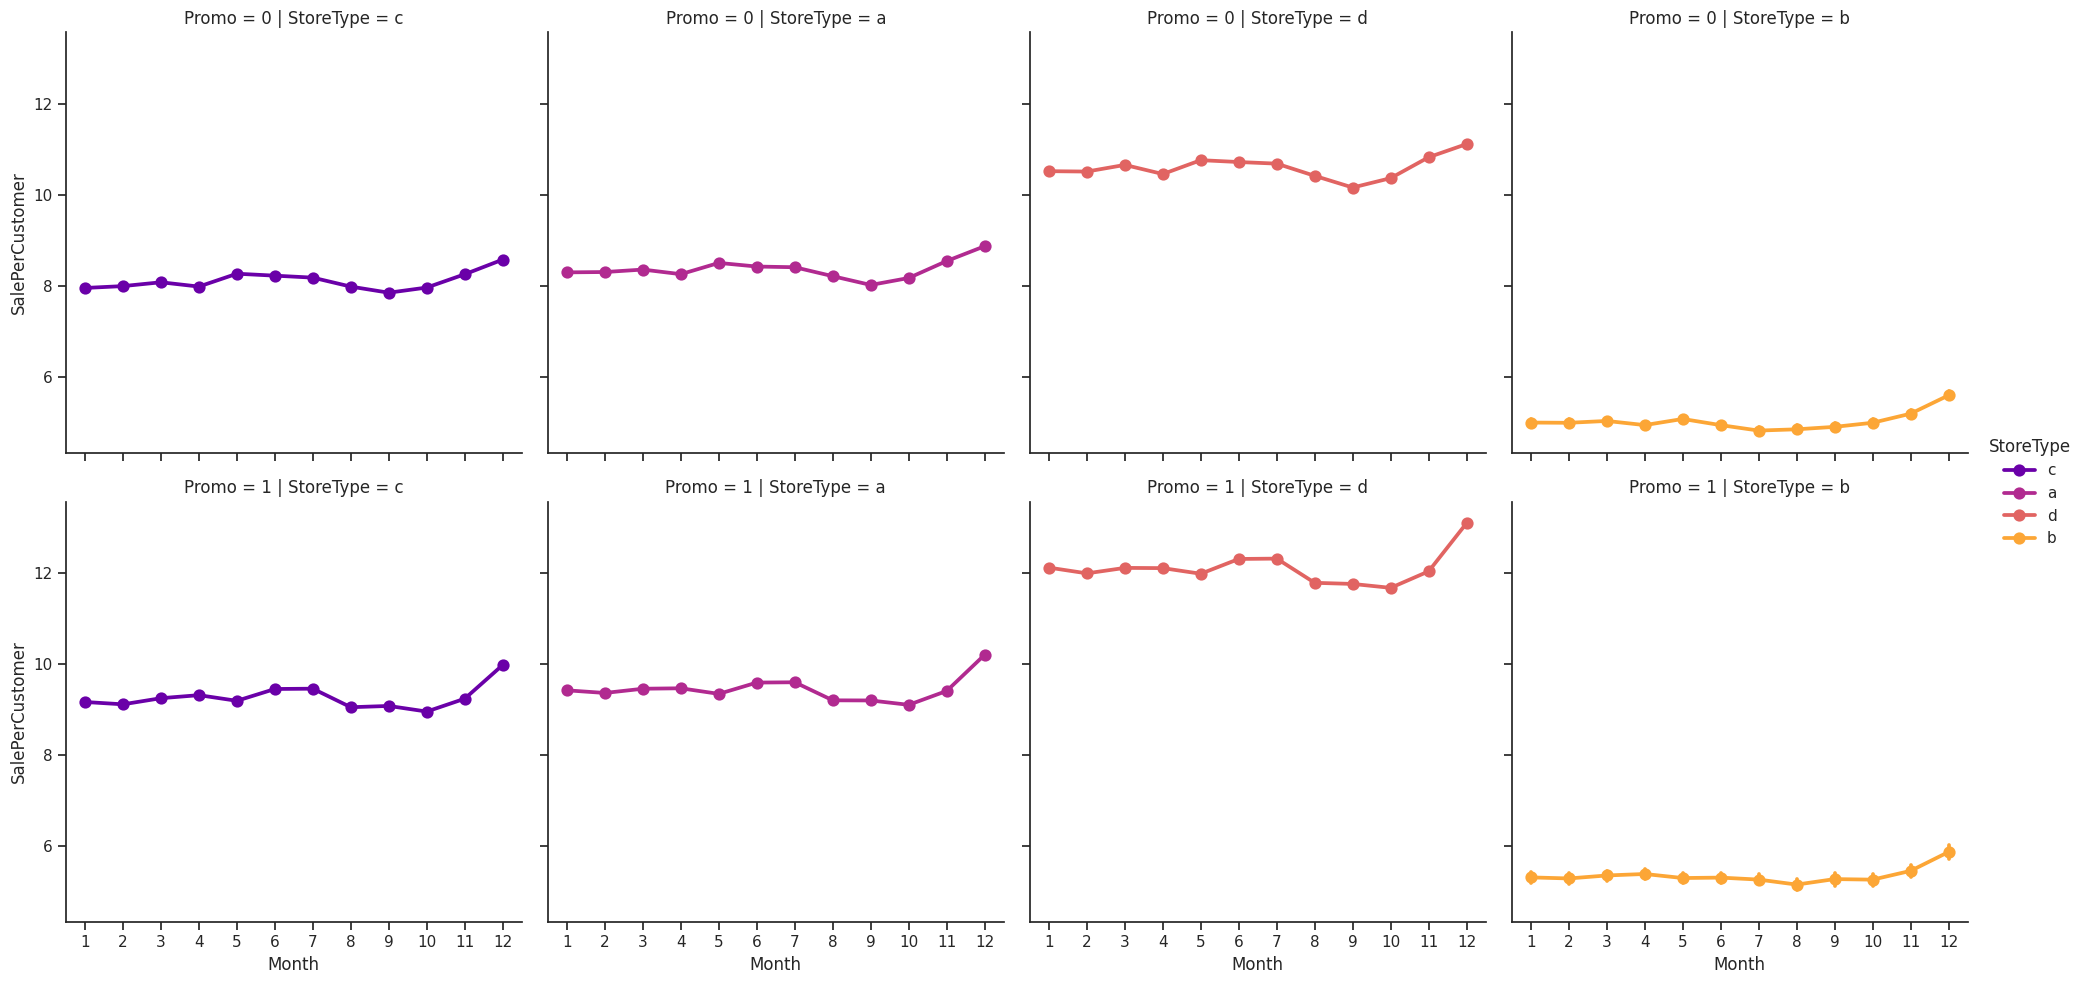

In [48]:
# sale per customer trends
sns.catplot(data = train_store, 
            x = 'Month', 
            y = 'SalePerCustomer', # Phân tích độ "chịu chi" của khách hàng
            col = 'StoreType', 
            row = 'Promo',     
            hue = 'StoreType', 
            palette = 'plasma',
            kind = 'point')    # Dùng dạng điểm nối để xem xu hướng

# Hiển thị biểu đồ
plt.show()

Aha! Eventhough the plots above showed `StoreType` B as the most selling and performant one, in reality it is not true. The highest `SalePerCustomer` amount is observed at the `StoreType` D, about 12€ with `Promo` and 10€ without. As for `StoreType` A and C it is about 9€. 

Low `SalePerCustomer` amount for `StoreType` B describes its Buyer Cart: there are a lot of people who shop essentially for "small" things (or in a little quantity). Plus we saw that overall this `StoreType` generated the least amount of sales and customers over the period.

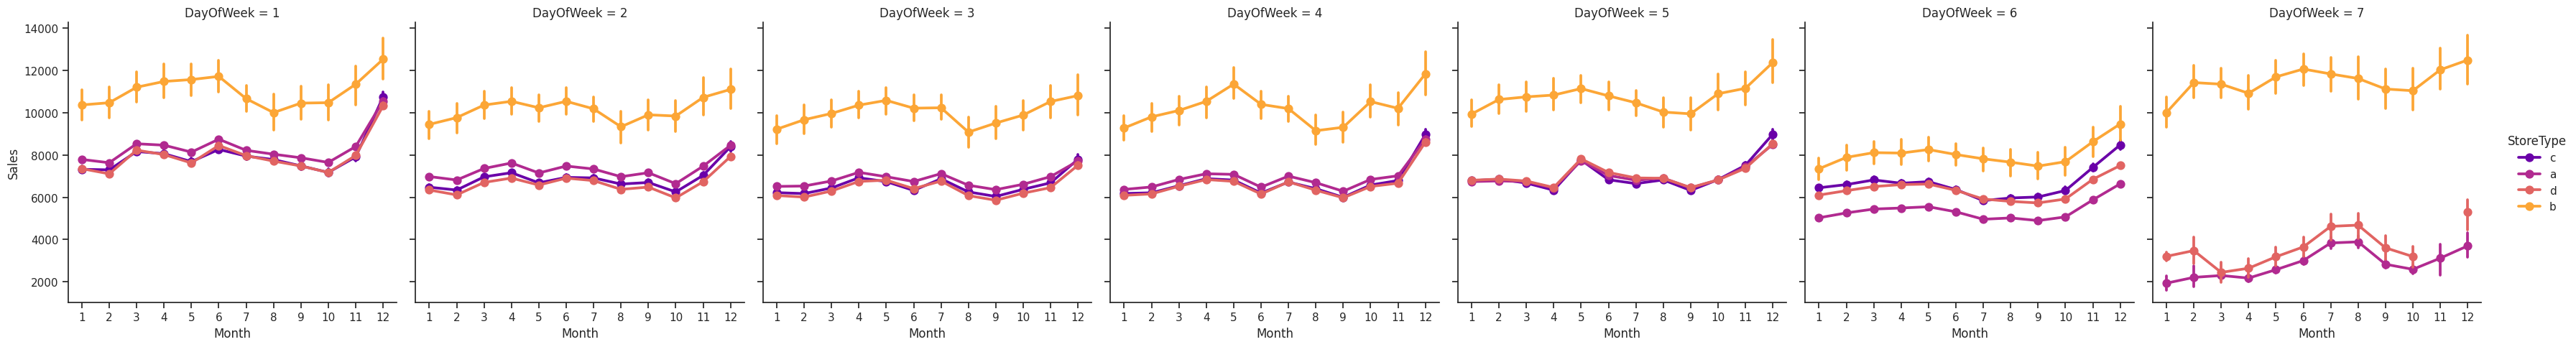

In [49]:

sns.catplot(data = train_store, 
            x = 'Month', 
            y = 'Sales', 
            col = 'DayOfWeek', # 7 cột cho 7 ngày
            hue = 'StoreType', # 4 màu cho 4 loại cửa hàng (để chung 1 ô dễ so sánh)
            palette = 'plasma',
            kind = 'point')

plt.show()

Nhóm thấy rằng toàn bộ các cửa hàng thuộc Loại C (StoreType C) đều đóng cửa vào các ngày Chủ nhật, trong khi các loại cửa hàng khác hầu như đều mở cửa. Một điểm khác nữa là các cửa hàng Loại D chỉ đóng cửa vào Chủ nhật trong khoảng thời gian từ tháng 10 đến tháng 12.

In [50]:
# cửa hàng nào mở vào cn
train_store[(train_store.Open == 1) & (train_store.DayOfWeek == 7)]['Store'].unique()

array([  85,  122,  209,  259,  262,  274,  299,  310,  335,  353,  423,
        433,  453,  494,  512,  524,  530,  562,  578,  676,  682,  732,
        733,  769,  863,  867,  931,  948, 1045, 1081, 1097, 1099,  877])

To complete our preliminary data analysis, we can add variables describing the period of time during which competition and promotion were opened:

In [51]:
# competition open time (in months)
train_store['CompetitionOpen'] = 12 * (train_store.Year - train_store.CompetitionOpenSinceYear) + \
        (train_store.Month - train_store.CompetitionOpenSinceMonth)
    
# Promo open time
train_store['PromoOpen'] = 12 * (train_store.Year - train_store.Promo2SinceYear) + \
        (train_store.WeekOfYear - train_store.Promo2SinceWeek) / 4.0

# replace NA's by 0
train_store.fillna(0, inplace = True)

# average PromoOpen time and CompetitionOpen time per store type
train_store.loc[:, ['StoreType', 'Sales', 'Customers', 'PromoOpen', 'CompetitionOpen']].groupby('StoreType').mean()

,Sales,Customers,PromoOpen,CompetitionOpen
StoreType,,,,
a,6925.697986,795.422370,12918.492198,7115.514452
b,10233.380141,2022.211825,17199.328069,11364.495244
c,6933.126425,815.538073,12158.636107,6745.418694
d,6822.300064,606.353935,10421.916846,9028.526526


Loại cửa hàng A, dù là loại bán chạy nhất và đông khách nhất, dường như không phải là nhóm chịu áp lực cạnh tranh từ đối thủ mạnh mẽ nhất. Thay vào đó, vị trí này lại thuộc về Loại cửa hàng B – đây cũng chính là loại có thời gian triển khai các đợt khuyến mãi kéo dài nhất.

### Correlational Analysis

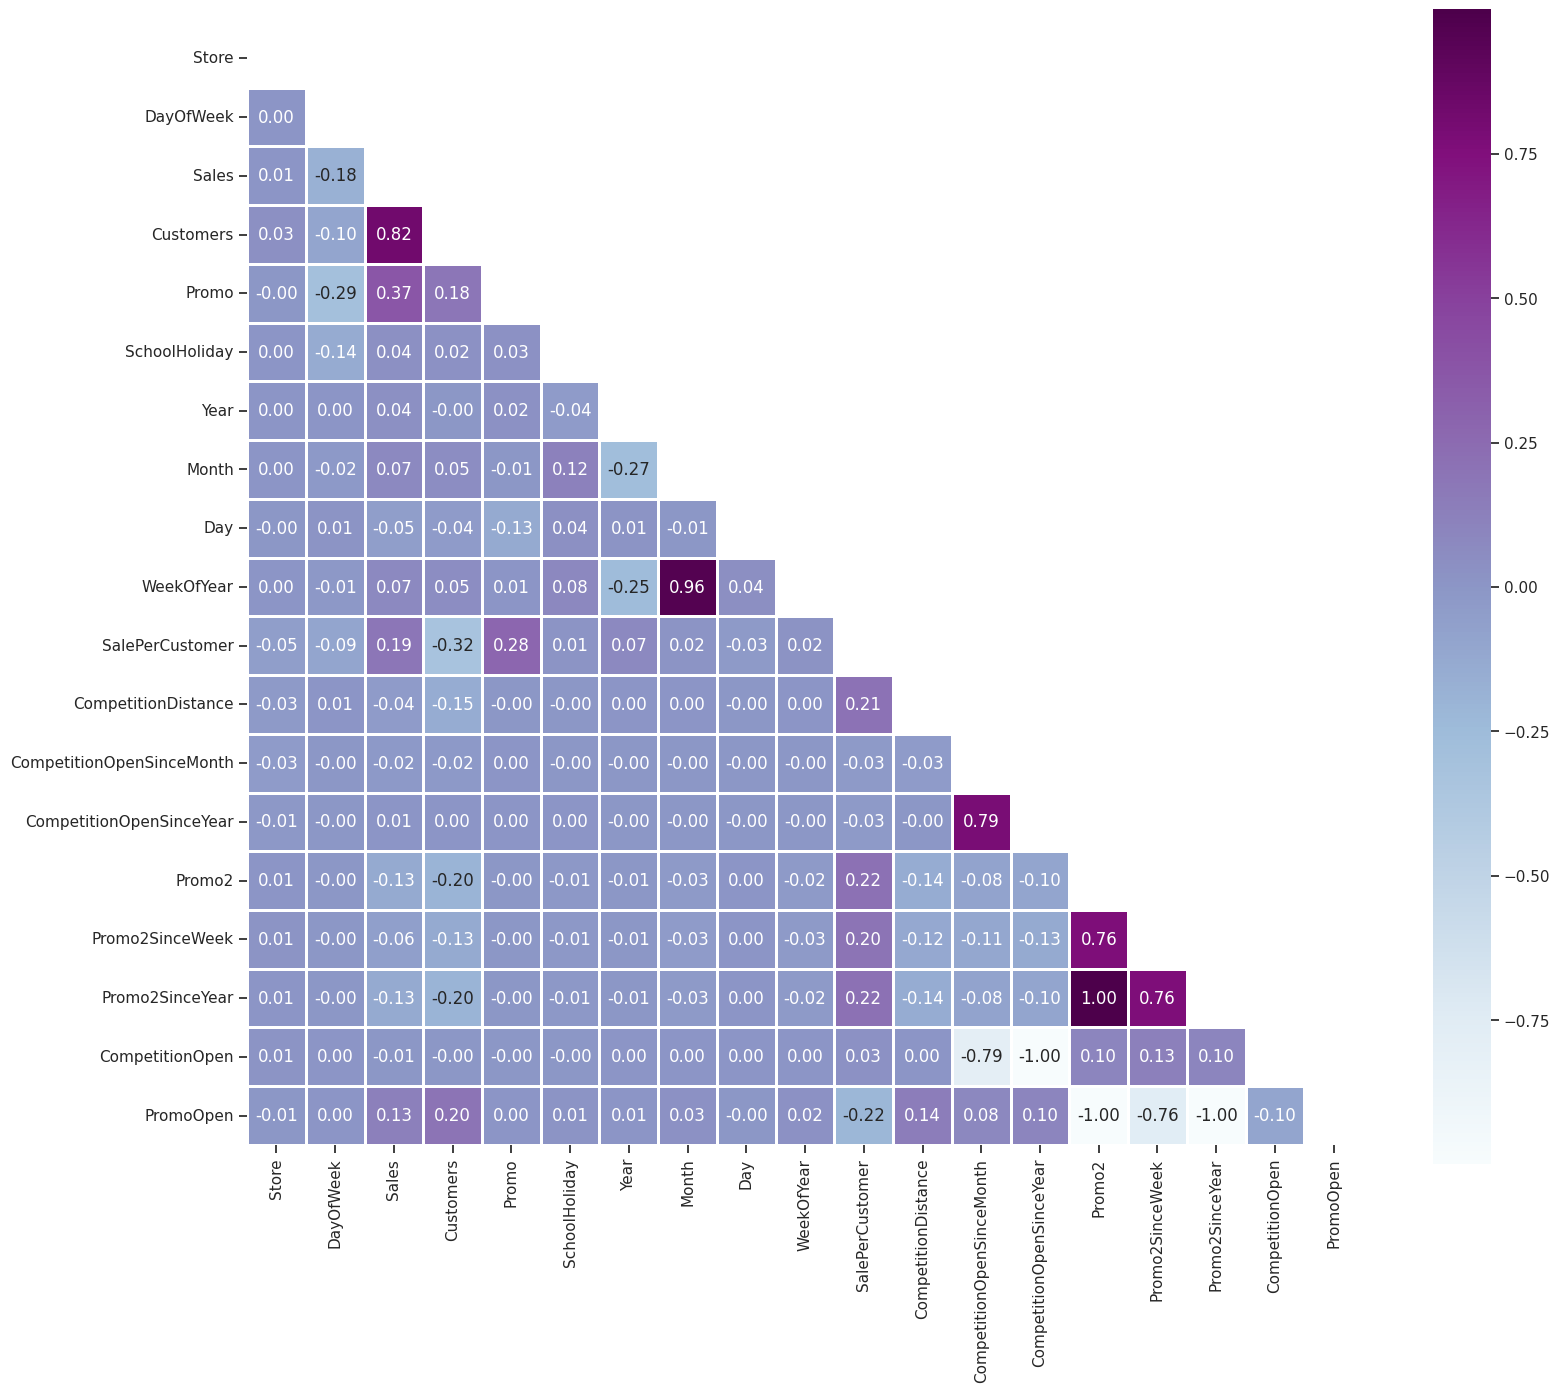

In [52]:
corr_all = train_store.drop('Open', axis = 1).corr(numeric_only=True)

mask = np.zeros_like(corr_all, dtype=bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize = (18, 15))

sns.heatmap(corr_all, 
            mask = mask,
            square = True, 
            linewidths = 2.0, 
            ax = ax, 
            cmap = "BuPu", 
            annot = True, 
            fmt = ".2f") 

plt.show()

Có một mối tương quan thuận mạnh mẽ giữa Doanh thu (Sales) và Lượng khách hàng (Customers) của một cửa hàng. Chúng ta cũng có thể quan sát thấy mối tương quan thuận giữa việc cửa hàng đang triển khai chương trình khuyến mãi (Promo bằng 1) và Lượng khách hàng.

Tuy nhiên, ngay khi cửa hàng tiếp tục thực hiện một chương trình khuyến mãi kéo dài/liên tiếp (Promo2 bằng 1), lượng Khách hàng và Doanh thu dường như giữ nguyên hoặc thậm chí giảm xuống. Điều này được thể hiện qua màu sắc nhạt của tương quan nghịch trên bản đồ nhiệt (heatmap). Mối tương quan nghịch tương tự cũng được ghi nhận giữa việc có chương trình khuyến mãi tại cửa hàng và các ngày trong tuần (DayOfWeek).

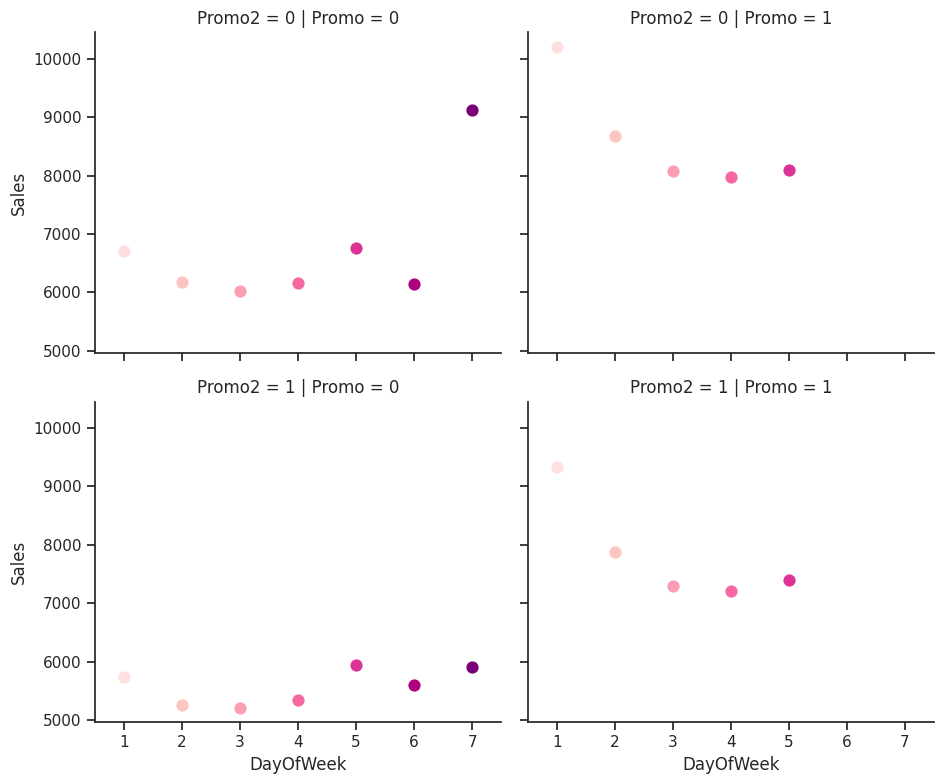

In [53]:
sns.catplot(
    data=train_store,
    x='DayOfWeek',
    y='Sales',
    col='Promo',      # chia theo Promo
    row='Promo2',     # chia theo Promo2
    kind='point',
    palette='RdPu',
    errorbar=None,
    height=4,
    aspect=1.2
)

plt.tight_layout()
plt.show()

Trường hợp không có khuyến mãi: Khi cả Promo và Promo2 đều bằng 0, Doanh thu (Sales) có xu hướng đạt đỉnh vào Chủ nhật. Tuy nhiên, cần lưu ý rằng các cửa hàng Loại C (StoreType C) không làm việc vào Chủ nhật. Vì vậy, con số này chủ yếu phản ánh dữ liệu từ các cửa hàng loại A, B và D.

Trường hợp có khuyến mãi: Ngược lại, các cửa hàng đang chạy chương trình khuyến mãi thường đạt doanh thu cao nhất vào thứ Hai. Đây có thể là một chỉ số quan trọng cho các chiến dịch marketing của Rossmann. Xu hướng tương tự cũng xuất hiện ở các cửa hàng chạy cả hai chương trình khuyến mãi cùng lúc (Promo và Promo2 đều bằng 1).

Về hiệu quả của Promo2: Riêng chương trình Promo2 dường như không liên quan đến bất kỳ thay đổi đáng kể nào về mức doanh thu. Điều này cũng được minh chứng bởi vùng màu xanh nhạt trên bản đồ nhiệt (heatmap) ở phía trên.

---

### Kết luận

Cửa hàng bán nhiều nhất và đông nhất là A 

Tỉ lệ "Sale per Customer" của D chỉ ra rằng khách hàng của nó mua rất sộp. Tức là hãng có thể tăng cường mặt hàng ở các store này 

Tỉ lệ "Sale per Customer" thấp của B chỉ ra rằng người ở đây có thể mua mấy món lặt vặt. Mặc dù, của hàng B bán ra và hút ít khách nhất, nhưng nó lại tiềm năng nhất

Khách hàng thường mua vào thứ 2 nếu có Promo và Sunday nếu như không có Promo 

Promo2 không có ảnh hưởng gì lắm tới doanh số bán, thậm chí nếu kéo dài, doanh số còn có thể giảm. 

# Thực hiện chuẩn hóa dữ liệu để train

thực hiện chuẩn hóa log hàm sales 

In [54]:
train_store.loc[:,'Sales']

0          5263
1          6064
2          8314
3         13995
4          4822
          ...  
844333     3375
844334    10765
844335     5035
844336     4491
844337     5961
Name: Sales, Length: 844338, dtype: int64

In [55]:
train_store.Sales = np.log1p(train_store.Sales)

In [56]:
train_store.shape

(844338, 25)

In [57]:
train_store.Date.dtype

dtype('<M8[us]')

In [58]:
train.Day.dtype

dtype('int32')

In [59]:
train.index

RangeIndex(start=0, stop=844338, step=1)

In [60]:
train_store.index

RangeIndex(start=0, stop=844338, step=1)

In [61]:
train_store = train_store.set_index('Date')
train_store.index.dtype

dtype('<M8[us]')

tách ra tập holdout for evaluating

In [63]:
max_date = train_store.index.max()
cutoff_date = max_date - pd.Timedelta(weeks=6)
print("Last day", max_date)
print("First day", cutoff_date)

train_set = train_store[train_store.index <= cutoff_date]
holdout_set = train_store[train_store.index > cutoff_date]

print("total shape", train_store.shape)
print("train_set", train_set.shape)
print("holdout_set", holdout_set.shape)

Last day 2015-07-31 00:00:00
First day 2015-06-19 00:00:00
total shape (844338, 24)
train_set (804056, 24)
holdout_set (40282, 24)


In [64]:
train_store.to_csv('train_store.csv')
train_set.to_csv('train_set.csv')
holdout_set.to_csv('holdout_set.csv')